# Explore and understand data

### Imports

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

### Read data

In [70]:
production = pd.read_csv("../data/bronze/wells_production.csv")
wells = pd.read_csv("../data/bronze/listed_wells.csv")

## 1. Production Dataset

### Dataset structure

In [71]:
print(f"Shape: {production.shape[0]:,} rows × {production.shape[1]} columns")
pd.DataFrame({"Data Type": production.dtypes.astype(str) })

Shape: 405,996 rows × 40 columns


,Data Type
idempresa,object
anio,int64
mes,int64
idpozo,int64
prod_pet,float64
prod_gas,float64
prod_agua,float64
iny_agua,float64
iny_gas,float64
iny_co2,float64


The production dataset contains 405,996 records and 40 attributes describing monthly oil, gas and water production, injection activities, operational characteristics and geographical information for Argentine wells.

### Missing values

In [72]:
missing_df = pd.DataFrame({"Missing Values": production.isna().sum(),"Percentage (%)": (production.isna().sum() / len(production) * 100).round(2)})
missing_df = (missing_df.sort_values("Missing Values", ascending=False).head(10))
display(missing_df)

,Missing Values,Percentage (%)
vida_util,397379,97.88
observaciones,382947,94.32
subclasificacion,910,0.22
clasificacion,910,0.22
tipoextraccion,605,0.15
tipopozo,605,0.15
tipoestado,605,0.15
sub_tipo_recurso,440,0.11
idempresa,0,0.00
formacion,0,0.00


### Cardinality 

In [73]:
unique_values = ( production.nunique() .reset_index())
unique_values.columns = ["Column", "Unique Values"]
display(unique_values.sort_values( by="Unique Values", ascending=False))

,Column,Unique Values
5,prod_gas,185556
4,prod_pet,139356
6,prod_agua,128588
11,tef,19746
17,fechaingreso,9949
3,idpozo,4929
22,sigla,4744
32,coordenadax,4690
33,coordenaday,4435
24,profundidad,2843


### Grain

In [74]:
duplicates_by_key = production[["idpozo", "anio", "mes"]].duplicated().sum()
print(f"Duplicate records by idpozo-anio-mes: {duplicates_by_key:,}")

records_per_well = ( production.groupby("idpozo").size().describe() )
display(records_per_well.to_frame(name="records_per_well"))

Duplicate records by idpozo-anio-mes: 0


,records_per_well
count,4929.000000
mean,82.368837
std,57.386091
min,1.000000
25%,31.000000
50%,80.000000
75%,125.000000
max,244.000000


### Temporal distribution

In [75]:
production["empresa"].nunique()

55

In [76]:
year_min = production["anio"].min()
year_max = production["anio"].max()
print(f"Year range: {year_min} - {year_max}")

unique_periods = production[["anio", "mes"]].drop_duplicates().shape[0]
print(f"Unique year-month periods: {unique_periods:,}")

records_by_year = ( production.groupby("anio").size().reset_index(name="records"))
display(records_by_year)

Year range: 2006 - 2026
Unique year-month periods: 244


,anio,records
0,2006,2368
1,2007,2442
2,2008,2280
3,2009,1698
4,2010,2038
5,2011,2599
6,2012,3640
7,2013,5184
8,2014,8777
9,2015,12841


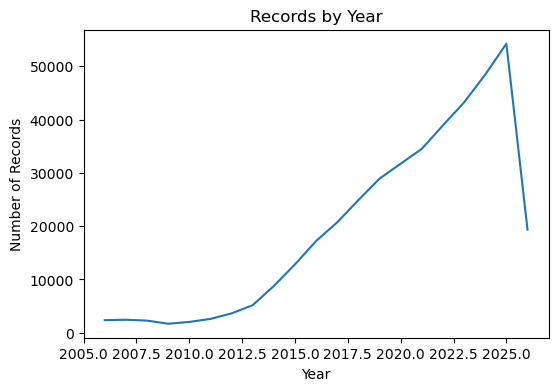

In [77]:
records_by_year = production.groupby("anio").size()
plt.figure(figsize=(6, 4))
records_by_year.plot(kind="line")
plt.title("Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.show()

### Companies

In [78]:
total_companies = production["empresa"].nunique()
print(f"Total companies: {total_companies:,}")

company_distribution = (production["empresa"].value_counts().reset_index())
company_distribution.columns = ["Company", "Records"]
display(company_distribution)

# Company consistency per well
company_per_well = (production.groupby("idpozo")["empresa"].nunique().value_counts().sort_index().reset_index())
company_per_well.columns = ["Companies per Well","Number of Wells"]

display(company_per_well)

Total companies: 55


,Company,Records
0,YPF S.A.,221496
1,CAPEX S.A.,20705
2,PLUSPETROL S.A.,20378
3,PAN AMERICAN ENERGY SL,19109
4,TOTAL AUSTRAL S.A.,15245
5,COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.,15232
6,TECPETROL S.A.,14821
7,PAMPA ENERGIA S.A.,12743
8,SHELL ARGENTINA S.A.,8505
9,YSUR ENERGÍA ARGENTINA S.R.L.,7721


,Companies per Well,Number of Wells
0,1,3927
1,2,646
2,3,194
3,4,139
4,5,21
5,6,2


### Wells

In [79]:
total_wells = production["idpozo"].nunique()
print(f"Total wells: {total_wells:,}")

records_per_well = (production.groupby("idpozo").size().describe().to_frame(name="Value"))
display(records_per_well)

well_types = (production["tipopozo"].value_counts().reset_index())
well_types.columns = ["Well Type", "Records"]
display(well_types)

Total wells: 4,929


,Value
count,4929.000000
mean,82.368837
std,57.386091
min,1.000000
25%,31.000000
50%,80.000000
75%,125.000000
max,244.000000


,Well Type,Records
0,Gasífero,221257
1,Petrolífero,156071
2,Otro tipo,27320
3,Sumidero,644
4,Inyección de Agua,56
5,Inyección de Gas,43


### Geography

In [80]:
province_distribution = (production["provincia"].value_counts().reset_index())
province_distribution.columns = ["Province", "Records"]

basin_distribution = (production["cuenca"].value_counts().reset_index())
basin_distribution.columns = ["Cuenca", "Records"]
display(province_distribution)
display(basin_distribution)

,Province,Records
0,Neuquén,357889
1,Rio Negro,28713
2,Santa Cruz,15899
3,Mendoza,3057
4,Chubut,253
5,Salta,185


,Cuenca,Records
0,NEUQUINA,389659
1,AUSTRAL,15570
2,GOLFO SAN JORGE,582
3,NOROESTE,185


In [81]:
location_consistency = pd.concat([
    production.groupby("idpozo")["provincia"].nunique().value_counts().rename("Province"),
    production.groupby("idpozo")["cuenca"].nunique().value_counts().rename("Cuenca"),
    production.groupby("idpozo")["areayacimiento"].nunique().value_counts().rename("Oil Field Area")
], axis=1).fillna(0)

display(location_consistency)

,Province,Cuenca,Oil Field Area
1,4929,4929,4929


## 2. Wells Dataset

### Dataset structure

In [82]:
print(f"Shape: {wells.shape[0]:,} rows × {wells.shape[1]} columns")
pd.DataFrame({"Data Type": wells.dtypes.astype(str) })

Shape: 84,242 rows × 51 columns


,Data Type
idpozo,int64
sigla,object
formprod,object
idempresa,object
idareapermisoconcesion,object
idareayacimiento,object
idcuenca,object
idprovincia,object
codigopropio,object
nombrepropio,object


### Missing values

In [83]:
missing_w = pd.DataFrame({"Missing Values": wells.isna().sum(),"Percentage (%)": (wells.isna().sum() / len(wells) * 100).round(2)})
missing_w = (missing_w.sort_values("Missing Values", ascending=False).head(25))
display(missing_w)

,Missing Values,Percentage (%)
adjiv_fecha_abandono,80101,95.08
subtipo_reservorio,79612,94.50
adjiv_subtipo_reservorio,79525,94.40
fecha_data,68750,81.61
fechadeingreso,68750,81.61
adjiv_fecha_inicio_term,35870,42.58
adjiv_fecha_fin_term,35869,42.58
adjiv_capacidad_perf,33911,40.25
comp_perf,33629,39.92
adjiv_comp_perf,33629,39.92


### Cardinality

In [84]:
unique_values_wells = ( wells.nunique().reset_index())
unique_values_wells.columns = ["Column", "Unique Values"]
display(unique_values_wells.sort_values( by="Unique Values", ascending=False))

,Column,Unique Values
0,idpozo,84242
1,sigla,77061
10,coordenadax,74827
11,coordenaday,73386
9,nombrepropio,72260
40,petroleo,65240
8,codigopropio,62510
42,agua,61379
41,gas,56971
43,periodo,56395


### Well uniqueness

In [85]:
wells["idpozo"].duplicated().sum()

0

Checked uniqueness of id just in case, one record per well

### Depth

In [86]:
depth_summary = (wells["profundidad"].describe().to_frame(name="Depth") )
display(depth_summary)

,Depth
count,84242.000000
mean,1698.195063
std,1736.239076
min,0.000000
25%,1028.000000
50%,1583.000000
75%,2345.000000
max,378939.000000


In [87]:
print(
    f"Wells with missing depth: "
    f"{wells['profundidad'].isna().sum():,}"
)

print(
    f"Wells with depth <= 0: "
    f"{(wells['profundidad'] <= 0).sum():,}"
)

Wells with missing depth: 0
Wells with depth <= 0: 10,254


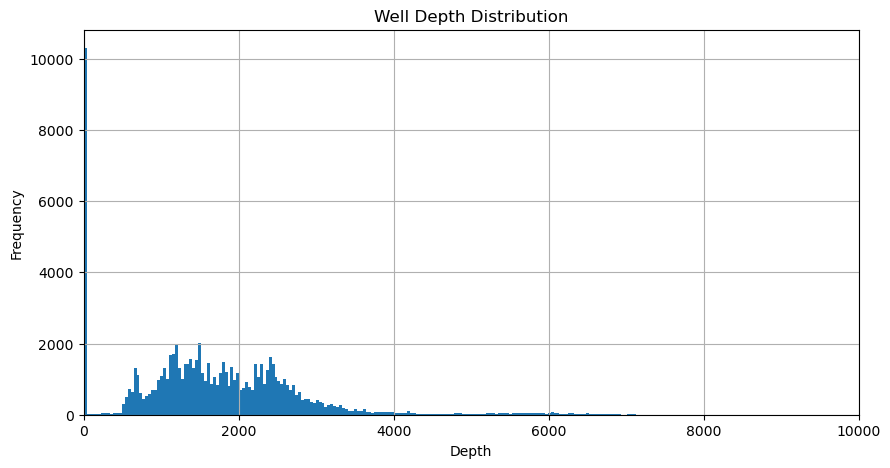

In [88]:
plt.figure(figsize=(10, 5))

wells["profundidad"].hist(bins=10000)

plt.xlim(0, 10000)

plt.title("Well Depth Distribution")
plt.xlabel("Depth")
plt.ylabel("Frequency")
plt.show()

### Reservoir

In [89]:
reservoir_type = (wells["tipo_reservorio"].value_counts().reset_index())

reservoir_type.columns = ["Reservoir Type", "Wells"]
subreservoir_type = (wells["subtipo_reservorio"].value_counts().reset_index())
subreservoir_type.columns = ["Reservoir Subtype", "Wells"]

formation_distribution = (wells["formprod"].value_counts().head(20).reset_index())
formation_distribution.columns = ["Formation", "Wells"]

display(reservoir_type)
display(subreservoir_type)
display(formation_distribution)

,Reservoir Type,Wells
0,CONVENCIONAL,57690
1,NO CONVENCIONAL,4633
2,SIN RESERVORIO,396
3,NO DISCRIMINADO,5


,Reservoir Subtype,Wells
0,SHALE,3014
1,TIGHT,1616


,Formation,Wells
0,BBAR,9197
1,CORI,8566
2,CSEC,8489
3,GCHU,8021
4,MELC,4149
5,QTUC,4019
6,AGRI,3948
7,VMUT,3183
8,FIMP,2724
9,HUIT,2631


### Location

In [90]:
province_distribution = (wells["provincia"].value_counts().reset_index())
province_distribution.columns = ["Province", "Wells"]

basin_distribution = (wells["cuenca"].value_counts().reset_index())
basin_distribution.columns = ["Basin", "Wells"]
field_distribution = (wells["areayacimiento"].value_counts().head(20).reset_index())

field_distribution.columns = ["Field Area", "Wells"]

display(province_distribution)
display(basin_distribution)
display(field_distribution)

,Province,Wells
0,Santa Cruz,23580
1,Chubut,22298
2,Neuquén,18950
3,Mendoza,8744
4,Rio Negro,5646
5,La Pampa,2710
6,Tierra del Fuego,1242
7,Salta,896
8,Estado Nacional,65
9,Formosa,65


,Basin,Wells
0,GOLFO SAN JORGE,44045
1,NEUQUINA,32366
2,CUYANA,3684
3,AUSTRAL,3133
4,NOROESTE,996
5,NORESTE,11
6,ÑIRIHUAU,2
7,ARGENTINA NORTE,1
8,CAÑADON ASFALTO,1


,Field Area,Wells
0,PUESTO HERNANDEZ,2568
1,MANANTIALES BEHR,2512
2,LOS PERALES,2311
3,CAMPAMENTO CENTRAL - BELLA VISTA ESTE,2233
4,DIADEMA,2118
5,EL HUEMUL,1962
6,CAÑADON LEON,1721
7,CAÑADON SECO,1648
8,EL TORDILLO,1620
9,EL TRAPIAL,1359


### Classification

In [91]:
classification_distribution = (wells["clasificacion"].value_counts().reset_index())
classification_distribution.columns = ["Classification","Wells"]

subclassification_distribution = (wells["subclasificacion"].value_counts().reset_index())
subclassification_distribution.columns = ["Subclassification","Wells"]

completion_distribution = (wells["comp_perf"].value_counts().reset_index())
completion_distribution.columns = ["Completion Type","Wells"]

display(classification_distribution)

,Classification,Wells
0,EXPLOTACION,56851
1,EXPLORACION,5432
2,SERVICIO,3987
3,ALMACENAMIENTO,33


In [92]:
display(subclassification_distribution)

,Subclassification,Wells
0,DESARROLLO,50767
1,AVANZADA,6277
2,EXPLORACION,3844
3,INYECTOR DE AGUA,3688
4,EXTENSION,848
5,EXPLORATORIO PROFUNDO,322
6,INYECTOR TERCIARIA,181
7,ESTUDIO,107
8,CONTROL,97
9,SUMIDERO,61


In [93]:
display(completion_distribution)

,Completion Type,Wells
0,SIN DATO,12328
1,YPF,7658
2,Pride International,6096
3,San Antonio Internacional,5370
4,DLS Argentina,4928
5,Petreven,2656
6,Nabors International Argentina,1386
7,Venver,1355
8,Almea Austral,1315
9,Helmerich & Payne,1266


In [94]:
display(wells["clasificacion"].value_counts().tail(10))

clasificacion
EXPLOTACION       56851
EXPLORACION        5432
SERVICIO           3987
ALMACENAMIENTO       33
Name: count, dtype: int64

In [95]:
display(wells["subclasificacion"].value_counts().tail(10))

subclasificacion
EXPLORATORIO PROFUNDO    322
INYECTOR TERCIARIA       181
ESTUDIO                  107
CONTROL                   97
SUMIDERO                  61
PRODUCTOR DE AGUA         48
ALMACENAMIENTO DE GAS     29
EXPLORATORIO SOMERO       18
INYECTOR DE GAS            9
INYECTOR DE VAPOR          7
Name: count, dtype: int64

## 3. Relationship Analysis

In [96]:
production_wells = set( production["idpozo"] )
master_wells = set( wells["idpozo"] )

print( "Production wells:", len( production_wells ) )
print( "Master wells:", len( master_wells ) )
print( "Intersection:", len( production_wells & master_wells ) )

Production wells: 4929
Master wells: 84242
Intersection: 4633


In [97]:
missing_in_wells = production_wells - master_wells
print(f"Wells in produciton missing in listed wells: {len( missing_in_wells )}")

Wells in produciton missing in listed wells: 296


-> Productive wells missing in dataset wells

In [98]:
missing_in_production = master_wells - production_wells
print(f"Wells nos used in produciton: {len( missing_in_production )}")

Wells nos used in produciton: 79609


### Consistency

In [99]:
merged = production.merge( wells, on="idpozo", how="inner", suffixes=("_prod", "_well"))

consistency_summary = pd.DataFrame({
    "Field": [
        "provincia",
        "cuenca",
        "areayacimiento"
    ],
    "Match Rate (%)": [
        (merged["provincia_prod"] == merged["provincia_well"]).mean() * 100,
        (merged["cuenca_prod"] == merged["cuenca_well"]).mean() * 100,
        (merged["areayacimiento_prod"] == merged["areayacimiento_well"]).mean() * 100
    ]
}).round(2)

display(consistency_summary)

,Field,Match Rate (%)
0,provincia,100.00
1,cuenca,100.00
2,areayacimiento,99.79


In [100]:
trimmed_field_area_mismatches = (
    merged["areayacimiento_prod"].str.strip()
    != merged["areayacimiento_well"].str.strip()
).sum()

print(
    f"Field area mismatches after trimming spaces: "
    f"{trimmed_field_area_mismatches:,}"
)

Field area mismatches after trimming spaces: 0


In [101]:
missing_in_wells = set(production["idpozo"]) - set(wells["idpozo"])

missing_df = production[
    production["idpozo"].isin(missing_in_wells)
]

print(f"Wells missing in wells dataset: {len(missing_in_wells):,}")

display(
    missing_df[[
        "idpozo",
        "empresa",
        "provincia",
        "cuenca"
    ]]
    .drop_duplicates()
    .head(20)
)

Wells missing in wells dataset: 296


,idpozo,empresa,provincia,cuenca
20,145330,YSUR ENERGÍA ARGENTINA S.R.L.,Neuquén,NEUQUINA
66,145329,YSUR ENERGÍA ARGENTINA S.R.L.,Neuquén,NEUQUINA
8463,137007,YPF S.A.,Neuquén,NEUQUINA
10374,153313,YPF S.A.,Neuquén,NEUQUINA
10392,146207,YPF S.A.,Neuquén,NEUQUINA
23574,166873,YPF S.A.,Neuquén,NEUQUINA
23576,166874,YPF S.A.,Neuquén,NEUQUINA
23578,166875,YPF S.A.,Neuquén,NEUQUINA
23580,166876,YPF S.A.,Neuquén,NEUQUINA
23582,166877,YPF S.A.,Neuquén,NEUQUINA


In [102]:
missing_year_summary = (
    missing_df["anio"]
    .describe()
    .to_frame(name="Missing Wells Year Summary")
)

display(missing_year_summary)

missing_wells_by_year = (
    missing_df["anio"]
    .value_counts()
    .sort_index()
    .reset_index()
)

missing_wells_by_year.columns = ["Year", "Records"]

display(missing_wells_by_year)

,Missing Wells Year Summary
count,2704.000000
mean,2020.645710
std,4.958525
min,2008.000000
25%,2016.000000
50%,2021.000000
75%,2026.000000
max,2026.000000


,Year,Records
0,2008,6
1,2009,11
2,2010,17
3,2011,48
4,2012,60
5,2013,92
6,2014,142
7,2015,155
8,2016,167
9,2017,173


## Conclusions

### Production Dataset

The production dataset contains 405,996 records and 4,929 unique wells, covering the period from 2006 to 2026. The dataset follows a clear grain of one record per well per month, as no duplicates were found for the combination (idpozo, anio, mes). The data is heavily concentrated in Neuquina and the province of Neuquén. The dataset includes production and injection measures such as oil, gas, water, and CO₂ injection, making it a suitable candidate for the future fact table. Most wells appear repeatedly over time, with an average of 80 monthly observations per well, confirming the temporal nature of the dataset.


### Wells Dataset

The wells dataset contains 84,242 unique wells, with exactly one record per well, making it a natural source for a dimension table. Several attributes are available; including location, reservoir type, classification, depth, and operational information. Some columns contain a very high percentage of missing values (above 80–90%), suggesting that they should be carefully evaluated before being included in downstream layers. The dataset covers a broader universe of wells than the production dataset and includes wells from multiple places across Argentina.

### Relationship between datasets

The datasets can be integrated using idpozo as the business key. The relationship between the datasets is a one-to-many relationship, where a single well can be associated with multiple monthly production records. Out of the 4,929 wells present in the production dataset; 4,633 wells were found in the wells dataset, while 296 wells were not found in the wells catalog. These unmatched wells appear to be valid production records rather than data quality errors, as they belong primarily to major operators such as YPF and YSUR and are concentrated in Neuquina. A large proportion of these records are associated with recent years (2025–2026), suggesting possible synchronization or update differences between the source systems.


Regarding data consistency, for wells that exist in both datasets consistency checks showed excellent agreement. 
Attribute	Consistency
Province	100%
Basin (Cuenca)	100%
Field (Área Yacimiento)	100% after string normalization

The initial discrepancies found in the areayacimiento attribute were caused by trailing spaces and formatting differences rather than actual conflicts in the data. These results validate idpozo as the integration key and indicate that both datasets represent the same business entities consistently.


Based on the analysis, the following dimensional model is proposed:
fact_production
    Grain: one record per well per month
dim_well
    Grain: one record per well
dim_date
    Grain: one record per calendar date

The production dataset should become the fact table because it contains the business measures and temporal observations. The wells dataset should become the well dimension because it provides a single record per well with descriptive attributes. Since 296 production wells do not exist in the wells dataset, the integration process should use a LEFT JOIN from production to wells to avoid losing valid production records. For slowly changing dimensions, SCD Type 1 is the preferred approach because the source datasets do not provide historical tracking of attribute changes and the available well attributes are largely descriptive and static. The analysis supports a star schema centered on fact_production, with dim_well and dim_date as the core dimensions.